# 멀티턴 잔액 조회 — 되묻기 & 복수 계좌 선택

`01_balance_inquiry`는 한 턴에 끝나는 흐름이었습니다. 이번에는 에이전트가
계좌를 특정하지 못해 **멈추고 되묻는** 멀티턴을 다룹니다.

| | 단일 턴 (01) | 멀티턴 (02) |
|---|---|---|
| 입력 | "생활비 통장 잔액 얼마야?" | "잔액 얼마야?" |
| 계좌 특정 | 힌트로 확정 | 후보 2개 → 사용자에게 선택 요청 |
| 실행 | 한 번의 invoke | 멈춤(interrupt) → 답변으로 재개 |

## 핵심 개념 (LangGraph)

| 개념 | 역할 |
|---|---|
| `interrupt()` | input 스텝에서 그래프를 일시정지하고 질문 반환 ⏸ |
| checkpointer (`MemorySaver`) | 멈춘 시점의 state 저장. 대화 세션 = `thread_id` |
| `Command(resume=답)` | 사용자 답을 넣어 멈춘 지점부터 재개 ▶ |

## Part 0. 환경 설정

In [1]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command

from agent.data.mock_bank import MOCK_ACCOUNTS
from agent.graph import build_graph
from agent.service import _new_state

print("user_001의 계좌 (2개 — 힌트 없이는 특정 불가):")
for account in MOCK_ACCOUNTS["user_001"]:
    print(f"  - {account['account_name']}: {account['balance']:,}원")

user_001의 계좌 (2개 — 힌트 없이는 특정 불가):
  - 입출금통장: 1,250,000원
  - 생활비통장: 430,000원


## Part 1. 멀티턴 그래프 만들기

단일 턴과의 유일한 차이는 **checkpointer를 전달**하는 것입니다.

In [2]:
graph = build_graph(checkpointer=MemorySaver())
print("멀티턴 그래프 준비 완료")

멀티턴 그래프 준비 완료


되묻기 경로를 그림으로 보면: `verify_account --[select_needed]-->
ask_account_selection --[submitted]--> apply_account_selection` 루프입니다.

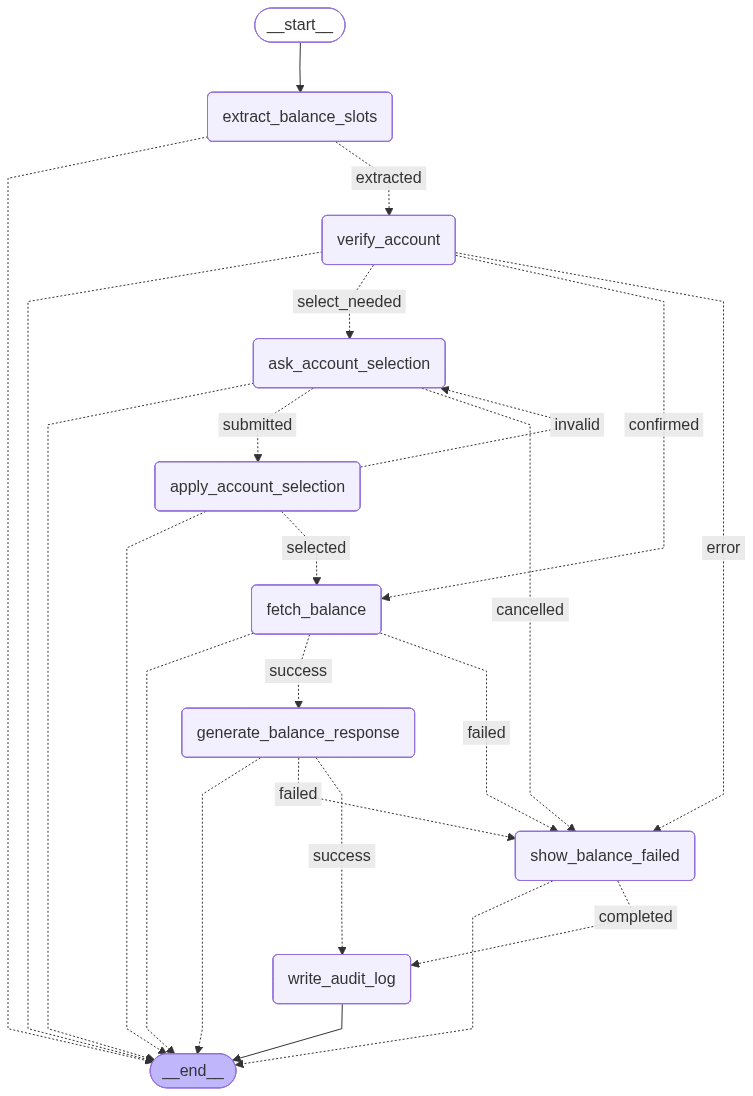

In [3]:
import yaml
from IPython.display import Image, display

from agent.paths import WORKFLOWS_PATH
from agent.subgraph_builder import build_workflow_graph

with open(WORKFLOWS_PATH, encoding="utf-8") as f:
    wf = yaml.safe_load(f)["wf_balance_inquiry"]

sub = build_workflow_graph("wf_balance_inquiry", wf)
try:
    display(Image(sub.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"PNG 렌더링 실패({type(e).__name__}) — mermaid 소스로 대체:\n")
    print(sub.get_graph().draw_mermaid())

## Part 2. 멀티턴 흐름 따라가기

### 2-1. 1턴 — 되물음 발생

계좌 힌트가 없어 `verify_account`가 `select_needed`를 반환하면 그래프는
`ask_account_selection`에서 **멈추고** `__interrupt__`를 반환합니다.

In [4]:
config = {"configurable": {"thread_id": "demo-1"}}

r1 = graph.invoke(_new_state("잔액 얼마야?", "user_001"), config=config)

payload = r1["__interrupt__"][0].value
print("⏸ 그래프가 멈추고 묻습니다:\n")
print(payload["prompt"])
print()
print("prompt_for =", payload["prompt_for"])

⏸ 그래프가 멈추고 묻습니다:

조회할 계좌를 선택해 주세요 (여러 개 가능):
  1. 입출금통장
  2. 생활비통장

prompt_for = balance.account_selection_input


### 2-2. 2턴 — 답을 넣어 재개

답변 파싱(`apply_account_selection`)은 **LLM 전용 tool**(폴백 없음)입니다.
키 없이 실행 중이므로 파싱이 실패해 `invalid` → 다시 묻습니다.
이것도 설계된 정상 동작입니다 (잘못된 답이면 재질문).

In [5]:
r2 = graph.invoke(Command(resume="1번"), config=config)

if r2.get("__interrupt__"):
    print("⏸ 다시 묻습니다 (키 없음 → LLM 파싱 실패 → invalid → 재질문):\n")
    print(r2["__interrupt__"][0].value["prompt"])
else:
    print("응답:", r2.get("final_response"))

⏸ 다시 묻습니다 (키 없음 → LLM 파싱 실패 → invalid → 재질문):

조회할 계좌를 선택해 주세요. 여러 개도 가능합니다.


### 2-3. 결정적 파서로 완주 확인

🤖 `OPENAI_API_KEY`가 있으면 "1번", "둘 다", "전부" 같은 자연어가 그대로
파싱됩니다. 키 없이 완주 경로를 보기 위해 테스트용 숫자 파서를 임시
등록합니다 (`agent/tests/test_chat_api.py`와 동일 로직).

In [6]:
from agent.tools.registry import TOOL_REGISTRY


def parse_selection_by_digits(state: dict) -> dict:
    """테스트용 대체 파서: 답변의 숫자로 계좌를 고른다."""
    data = state.get("data") or {}
    candidates = data.get("balance.account_candidates") or []
    reply = data.get("balance.account_selection_input", "")
    nums = [int(ch) for ch in reply if ch.isdigit()]
    nums = [n for n in nums if 1 <= n <= len(candidates)]
    if not nums:
        return {"route_key": "invalid"}
    return {
        "balance.selected_accounts": [candidates[n - 1] for n in nums],
        "route_key": "selected",
    }


original_parser = TOOL_REGISTRY["apply_account_selection"]
TOOL_REGISTRY["apply_account_selection"] = parse_selection_by_digits


def run_multiturn(first: str, reply: str, thread_id: str) -> str:
    config = {"configurable": {"thread_id": thread_id}}
    graph.invoke(_new_state(first, "user_001"), config=config)
    result = graph.invoke(Command(resume=reply), config=config)
    return result.get("final_response")


print("답변 '1번'   →", run_multiturn("잔액 얼마야?", "1번", "c-1"))
print("답변 '2번'   →", run_multiturn("잔액 얼마야?", "2번", "c-2"))
print("답변 '1, 2번' →", run_multiturn("잔액 얼마야?", "1번이랑 2번", "c-3"))

답변 '1번'   → 입출금통장 1,250,000원입니다.
답변 '2번'   → 생활비통장 430,000원입니다.
답변 '1, 2번' → 입출금통장 1,250,000원, 생활비통장 430,000원입니다.


### 실행 경로 확인

멀티턴 경로가 trace에 그대로 남습니다:
`verify_account [select_needed] → ask_account_selection [submitted] →
apply_account_selection [selected] → fetch_balance ...`

In [7]:
config = {"configurable": {"thread_id": "trace-demo"}}
graph.invoke(_new_state("잔액 얼마야?", "user_001"), config=config)
result = graph.invoke(Command(resume="1번"), config=config)

for t in result["execution_trace"]:
    print(f"  {t['step']} [{t['route_key']}]")

TOOL_REGISTRY["apply_account_selection"] = original_parser  # 원복

  extract_balance_slots [extracted]
  verify_account [select_needed]
  ask_account_selection [submitted]
  apply_account_selection [selected]
  fetch_balance [success]
  generate_balance_response [success]
  write_audit_log [logged]


## 정리

- 멈춤(⏸ interrupt) / 저장(checkpointer + thread_id) / 재개(▶ Command) —
  이 인프라는 **타인 송금의 승인·인증에서 그대로 재사용**됩니다.
- HTTP에서는 interrupt가 `status: waiting_input` + `thread_id` 회송으로
  번역됩니다 (`03_external_transfer.ipynb` Part 3).

→ 다음: `03_external_transfer.ipynb` — 승인 게이트가 있는 타인 송금